## Currently we are using existing memory ;; now want to do something so it will also create new memory while chating

* to making things simpler it will only creat new memory , it will not use existing memory

In [106]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, add_messages, MessagesState
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint, HuggingFaceEmbeddings
from typing import Annotated
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from pydantic import BaseModel, Field
import uuid
import json



load_dotenv()

True

In [107]:
llm= HuggingFaceEndpoint(
    model="Qwen/Qwen3-32B",
    task="text-generation",
    huggingfacehub_api_token= os.getenv("HUGGINGFACEHUB_API_TOKEN")
)

model= ChatHuggingFace(llm=llm) # llm will decide what to remember

In [108]:
class ChatState(MessagesState):
    messages: Annotated[list[BaseMessage], add_messages]


class MemoryDecision(BaseModel):
    should_write: bool= Field(description="Whether to store any memories")
    memories: list[str]= Field(default=list, description="Atomic user memories to store")


memory_extractor= model.with_structured_output(MemoryDecision, method='json_schema')

d:\Users\Aditya_Kumar\LangGraphCompushX\venv\lib\site-packages\pydantic\json_schema.py:2448: PydanticJsonSchemaWarning: Default value <class 'list'> is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


In [109]:
#1)  LTM store
store= InMemoryStore()

## create a namespace
user_id="u1"

namespace= ("users", user_id, "details")

In [110]:
def remember_only_node(state:ChatState, config:RunnableConfig, store:BaseStore):
    user_id= config['configurable']['user_id']

    namespcae= ('users', user_id, 'details')

    # take latest user message
    last_msg= state['messages'][-1].content

    # existing memory 
    existing_memory_items= store.search(namespcae)
    existing_memory= "\n".join(f"-{item.value['data']}" for item in existing_memory_items)

    ## LLm decide what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "only store stable, user-specific info (identity, perference,ongoing projects etc )\n"
                    "DO NOT store transient info\n"
                    "Return should_write=False if nothing is worth stroing.\n"
                    "Each memory should be a short atomic sentence.\n\n"
                    f"Existing memory {existing_memory}"
                )
            ),
            {"role":"user", "content":last_msg}
        ]
    )
    print(decision['should_write'], decision['memories'])
    

    if decision['should_write']:
        for mem in decision['memories']:
            store.put(namespcae, str(uuid.uuid4()), {"data":mem})

    # img: we are NOt using memory , not even responding with the LLM.
    # we just return a fixed acknowlegement

    return {"messages":[{"role":"assistant", "content":"Noted."}]}
    

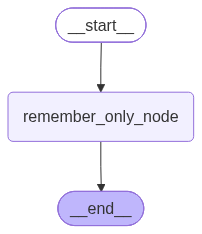

In [111]:
builder= StateGraph(ChatState)

builder.add_node('remember_only_node', remember_only_node)

builder.add_edge(START, 'remember_only_node')
builder.add_edge('remember_only_node', END)


# stm
checkpointer= InMemorySaver()

graph= builder.compile(checkpointer=checkpointer, store=store)
graph

In [ ]:
# first told -> My name is aditya
# sec -> I am doing doing BS in data science
#  third -> my name is aditya and I am intern at tata elxsi. I love playing footwall


config= {"configurable":{"thread_id":"1", "user_id":"u1"}}

init_state={"messages":[HumanMessage(content="my name is aditya and I am intern at tata elxsi. I love playing footwall")]}

result= graph.invoke(init_state, config=config)

result['messages'][-1].content

True ['Aditya is interning at Tata Elxsi.', 'Aditya loves playing footwall.']


'Noted.'

In [122]:
total_memories= store.search(namespace)

for mem in total_memories:
    print(mem.value['data'])


User's name is Aditya.
Aditya is pursuing a BS in Data Science.
Aditya is interning at Tata Elxsi.
Aditya loves playing footwall.


In [120]:
total_memories

[Item(namespace=['users', 'u1', 'details'], key='06f52ff8-72e1-4884-8b7f-156b837b25e8', value={'data': "User's name is Aditya."}, created_at='2026-08-22T15:49:17.802261+00:00', updated_at='2026-08-22T15:49:17.802261+00:00', score=None),
 Item(namespace=['users', 'u1', 'details'], key='90abce86-c503-4952-baf9-1be64c80f7e0', value={'data': 'Aditya is pursuing a BS in Data Science.'}, created_at='2026-08-22T15:50:10.317862+00:00', updated_at='2026-08-22T15:50:10.317862+00:00', score=None)]